In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import cmocean
from scipy.optimize import curve_fit

import warnings
warnings.filterwarnings('ignore')

from les_functions import find_psd_morr,find_psd_thom,get_wrf_for_psd,ob_n0_lambda


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
small, med,mb, big = 13, 15, 18, 20
# plt.rc('font',size=med)
plt.rc('axes',titlesize=med, labelsize=med)
plt.rc('xtick',labelsize=small)
plt.rc('ytick',labelsize=small)
plt.rc('legend',fontsize=med)
plt.rc('figure',titlesize=big)

## Compare Observed Snow PSD with Modeled PSD

**Goal**: Plot scatter plot of observed distribution points, colored by time. Then, overlay lines of simulated estimated PSD colored on the same time scale. 

Notes: 
 - Simulation has a resolution of 15 minutes, while observations have resolution of 1 minute. 
 - Take note of model height of simulated distribution...it IS above the surface.

In [3]:
# Use this function to open the PSD comparisons CSV to find start and end times for each window

def get_case_times(station,snow_type,ob_or_wrf,run_type,date=None,varbias=None):
    sc = pd.read_csv('LES_case_comparisons.txt')
#     print('VARBIAS',varbias)
    if varbias is None:
        if snow_type is not None:
            tstart_df = sc[f'{ob_or_wrf}_start'][(sc['snow_type']==snow_type)&(sc['station']==station)&(sc['run_type']==run_type)]
            tend_df = sc[f'{ob_or_wrf}_end'][(sc['snow_type']==snow_type)&(sc['station']==station)&(sc['run_type']==run_type)]
        elif snow_type is None:
            tstart_df = sc[f'{ob_or_wrf}_start'][(sc['station']==station)&(sc['run_type']==run_type)]
            tend_df = sc[f'{ob_or_wrf}_end'][(sc['station']==station)&(sc['run_type']==run_type)]
    elif varbias is not None:
        if len(varbias.split('_'))==3:
            var = varbias.split('_')[0]+'_'+varbias.split('_')[1]
            bias= varbias.split('_')[-1]
        else:
            var,bias = varbias.split('_')
        tstart_df = sc[f'{ob_or_wrf}_start'][(sc[var]==bias)&(sc['station']==station)&(sc['run_type']==run_type)]
        tend_df = sc[f'{ob_or_wrf}_end'][(sc[var]==bias)&(sc['station']==station)&(sc['run_type']==run_type)]

    tstart = pd.to_datetime(tstart_df.to_numpy())
    tend   = pd.to_datetime(tend_df.to_numpy())
        
    if date != None:
        if isinstance(date,int):
            tstart = tstart[(tstart.month==date)]
            tend   = tend[(tend.month==date)]
        elif isinstance(date,list):
            if (date[-1].hour != 0)|(date[0].hour != 0):
                tstart = tstart[(tstart.year==date[0].year)&(tstart.month==date[0].month)&(tstart.day==date[0].day)&(tstart.hour==date[0].hour)]
                tend   = tend[(tend.year==date[-1].year)&(tend.month==date[-1].month)&(tend.day==date[-1].day)&(tend.hour==date[1].hour)]
            else:
                tstart = tstart[(tstart.year==date[0].year)&(tstart.month==date[0].month)&(tstart.day==date[0].day)]
                tend   = tend[(tend.year==date[-1].year)&(tend.month==date[-1].month)&(tend.day==date[-1].day)]
        else:
            tstart = tstart[(tstart.year==date.year)&(tstart.month==date.month)&(tstart.day==date.day)]
            tend   = tend[(tend.year==date.year)&(tend.month==date.month)&(tend.day==date.day)]
    
    if (len(tstart)==0) | (len(tend)==0):
        print('returning empty times')
    elif (len(tstart)>1)|(len(tend)>1):
#         print(len(tstart))
        print('returning more than one time window')
    else:
        tstart,tend,=[tstart[0]],[tend[0]]
        
        
    return pd.to_datetime(tstart),pd.to_datetime(tend)


In [4]:
def get_model_data(datew,station,snow_type,run_dir,varbias=None,bins=[],wrf_match_bool=True):
    tstart_w,tend_w = get_case_times(station, snow_type, 'wrf', run_dir, date=datew,varbias=varbias)
    if len(tstart_w)==0:
        return np.nan
    
    print('testing',tstart_w)
    if len(tstart_w) > 1:
        index_cat_prev_size=0
        index_cat_sm = []
        for tsw,tstartw in enumerate(tstart_w):
            pdtime_range = pd.date_range(start=tstartw.floor(freq='H'),
                                         end=tend_w[tsw].ceil(freq='H'),
                                         freq='1H')#<-- Important!

            if 'morr' in run_dir:
                Ds,NDi = find_psd_morr(pdtime_range,station,run_dir,bins=bins/1000)
            elif 'thom' in run_dir:
                Ds,NDi = find_psd_thom(pdtime_range,station,run_dir,bins=bins/1000)

            # crop the resulting ND shape so that only the desired times are used
            indextime = pd.date_range(start=tstartw.floor(freq='H'),
                                      end=tend_w[tsw].ceil(freq='H'),
                                      freq='15min')
            iwstart = np.argwhere(indextime==tstartw)[0][0]
            iwend   = np.argwhere(indextime==tend_w[tsw])[0][0]
            NDi = NDi[iwstart:iwend+1,:]
            indextime = indextime[iwstart:iwend+1]
            if tsw==0:
                ND = NDi
                timeplot = indextime
            else:
                ND = np.concatenate((ND,NDi),axis=0)
                timeplot = np.hstack((timeplot,indextime))
                
            index_cat0 = np.zeros((ND.shape[0]-index_cat_prev_size))
            index_cat_prev_size = ND.shape[0]
            index_cat0[:] = int(tsw)
            index_cat_sm.append(index_cat0)
#             print(ND.shape,np.shape(index_cat_sm))
            print(index_cat_sm)

    elif len(tstart_w)==1:
            pdtime_range = pd.date_range(start=tstart_w[0].floor(freq='H'),
                                         end=tend_w[0].ceil(freq='H'),
                                         freq='1H')#<-- Important!

            if 'morr' in run_dir:
                Ds,ND = find_psd_morr(pdtime_range,station,run_dir,bins=bins/1000)
            elif 'thom' in run_dir:
                Ds,ND = find_psd_thom(pdtime_range,station,run_dir,bins=bins/1000)

            # crop the resulting ND shape so that only the desired times are used
            indextime = pd.date_range(start=tstart_w[0].floor(freq='H'),
                                      end=tend_w[0].ceil(freq='H'),
                                      freq='15min')
            timeplot= indextime
            iwstart = np.argwhere(indextime==tstart_w[0])[0][0]
            iwend   = np.argwhere(indextime==tend_w[0])[0][0]
            ND = ND[iwstart:iwend+1,:]
            index_cat_0 = np.zeros((ND.shape[0]))
            index_cat_0[:] = int(0)
            index_cat_sm = []
            index_cat_sm.append(index_cat_0)
#             print(ND.shape,np.shape(index_cat_sm))
            print(index_cat_sm)

    
    timeplot = pd.to_datetime(timeplot)

    new_list = []
#     if len(index_cat_sm)
    for j in range(len(index_cat_sm)):
        new_list = new_list+list(index_cat_sm[j])

    index_cat_sm = new_list
    
    wrf_match = np.zeros_like(ob_psd)
    index_cat = np.zeros_like(wrf_match[:,0])
    
    if wrf_match_bool is True:
#         print('Did I make it?')
        for i in range(len(ND)):
            tw = int(np.floor(len(ob_psd)/ len(ND)))
            if i == len(ND)-1:
#                 print('here',i,len(ND)-1)
                wrf_match[(i*tw):,:] = ND[i]/1000
                index_cat[(i*tw):] = index_cat_sm[i]
            else:
#                 print('test',index_cat_sm[i])
                wrf_match[(i*tw):(i*tw)+tw,:] = ND[i]/1000 # dividing by 1000 is very important!!!
                index_cat[(i*tw):(i*tw)+tw] = index_cat_sm[i]
        
    
    return wrf_match,timeplot,ND,index_cat,index_cat_sm


In [5]:
def get_ob_data(dateo,station,snow_type,run_dir,varbias=None):
    stncode = {'KMQT':'006','KAPX':'007','KBUF':''}
    # observation window
    tstart_o,tend_o = get_case_times(station, snow_type, 'obs', run_dir, date=dateo,varbias=varbias)
#     print(tstart_o,tend_o)
    if len(tstart_o)==0:
        return np.nan
    
#     if len(tstart_o)>1:
#         for t,ts in enumerate(tstart_o):
#             if t==0:
#                 pdtime_range = pd.date_range(start=ts,
#                                              end=tend_o[t],
#                                              freq='1min')#<-- Important!
#             else:
#                 pdtr = pd.date_range(start=ts,
#                                      end=tend_o[t],
#                                      freq='1min')#<-- Important!
#                 pdtime_range = np.hstack((pdtime_range,pdtr))
#         if tstart_o[0].day != tend_o[-1].day:
#             append = True
#             days = [tstart_o[0].day]
#             prevday = tstart_o[0].day

#             for t in pd.to_datetime(pdtime_range): # I MIGHT NEED TO FIX THIS
#                 if t.day != prevday:
#                     days.append(t.day)
#                 prevday = t.day
#         else:
#             append = False
    if len(tstart_o)>1:
        for t,ts in enumerate(tstart_o):
            if t==0:
                pdtime_range = pd.date_range(start=ts,
                                             end=tend_o[t],
                                             freq='1min')#<-- Important!
            else:
                pdtr = pd.date_range(start=ts,
                                     end=tend_o[t],
                                     freq='1min')#<-- Important!
                pdtime_range = np.hstack((pdtime_range,pdtr))
                        
        if tstart_o[0].month == tend_o[-1].month:
            if tstart_o[0].day != tend_o[-1].day:
                append = True
                days = [f'{tstart_o[0].month}_{tstart_o[0].day}']
                prevday = f'{tstart_o[0].month}_{tstart_o[0].day}'
                for t in pd.to_datetime(pdtime_range): # I MIGHT NEED TO FIX THIS
                    if t.day != prevday:
                        days.append(f'{t.month}_{t.day}')
                    prevday = f'{t.month}_{t.day}'
            else:
                append = False
        elif tstart_o[0].month != tend_o[-1].month:
            append = True
            days = [f'{tstart_o[0].month}_{tstart_o[0].day}']
            prevday = f'{tstart_o[0].month}_{tstart_o[0].day}'
            for t in pd.to_datetime(pdtime_range): 
                if (str(t.day) != prevday.split('_')[1])|(str(t.month) != prevday.split('_')[0]):
                    days.append(f'{t.month}_{t.day}')
                prevday = f'{t.month}_{t.day}'
                
#         print('testing',days)
            
    else:
        pdtime_range = pd.date_range(start=tstart_o[0],
                                     end=tend_o[0],
                                     freq='1min')#<-- Important!

        if tstart_o.day != tend_o.day:
            append = True
            days = [tstart_o[0].day]
            prevday = tstart_o[0].day
            for t in pdtime_range: # I MIGHT NEED TO FIX THIS
                if t.day != prevday:
                    days.append(t.day)
                prevday = t.day
        else:
            append = False

#     print(tstart_o)
            
    if station=='KBUF':
        pipdir = f'/nfs/turbo/seas-hutsona/les_data/PARSIVEL/'
    else:
        pipdir = f'/nfs/turbo/seas-hutsona/les_data/PIP/2022_{station[1:]}/particle_size_distributions/'
        
#     if append == True:
#         for f,day in enumerate(days):
#             try:
#                 ftime_str = f'{stncode[station]}{tstart_o[0].year}{tstart_o[0].month:02d}{day:02d}_dsd.nc'
#             except:
#                 ftime_str = f'{stncode[station]}{tstart_o[0].year}{tstart_o[0].month:02d}{day:02d}_dsd.nc'
#             if station=='KBUF':
#                 file = f'{pipdir}{tstart_o[0].year}{tstart_o[0].month:02d}{day:02d}_BUF.nc'
#             else:
#                 file = f'{pipdir}{ftime_str}'
#             fh = xr.open_dataset(file)

#             if station=='KBUF':
#                 psd1 = fh.dsd.data
#             else:
#                 psd1 = fh.psd.data
#             psd1[psd1==0.0] = np.nan
#             if f==0:
#                 psd = psd1
#             else:
#                 psd = np.concatenate((psd,psd1))
#             if f==0:
#                 time = pd.to_datetime(fh.time.data)
#             else:
#                 time = np.hstack((time,pd.to_datetime(fh.time.data)))
            
#             if station=='KBUF':
#                 bins = fh.diameter.data
#             else:
#                 bins= fh.bin_centers.data
    if append == True:
        for f,daym in enumerate(days):
            month,day = daym.split('_')
            month = int(month)
            day   = int(day)
            
            ftime_str = f'{stncode[station]}{tstart_o[0].year}{month:02d}{day:02d}_dsd.nc'
            if station=='KBUF':
                file = f'{pipdir}{tstart_o[0].year}{month:02d}{day:02d}_BUF.nc'
#                 print(file)
            else:
                file = f'{pipdir}{ftime_str}'
            fh = xr.open_dataset(file)

            if station=='KBUF':
                psd1 = fh.dsd.data
            else:
                psd1 = fh.psd.data
            psd1[psd1==0.0] = np.nan
            
            if f==0:
                psd = psd1
            else:
                psd = np.concatenate((psd,psd1))
            if f==0:
                time = pd.to_datetime(fh.time.data)
            else:
                time = np.hstack((time,pd.to_datetime(fh.time.data)))
            
            if station=='KBUF':
                bins = fh.diameter.data
            else:
                bins= fh.bin_centers.data
                
#             print('testing',time)
        time = pd.to_datetime(time)

    if append == False:
        try:
            ftime_str = f'{stncode[station]}{tstart_o[0].year}{tstart_o[0].month:02d}{tstart_o[0].day:02d}_dsd.nc'
        except:
            ftime_str = f'{stncode[station]}{tstart_o[0].year}{tstart_o[0].month:02d}{tstart_o[0].day:02d}_dsd.nc'
        file = f'{pipdir}{ftime_str}'
        if station=='KBUF':
            file = f'{pipdir}{tstart_o[0].year}{tstart_o[0].month:02d}{tstart_o[0].day:02d}_BUF.nc'
        fh = xr.open_dataset(file)

        if station=='KBUF':
            psd = fh.dsd.data
            bins= fh.diameter.data  
        else:
            psd = fh.psd.data
            bins= fh.bin_centers.data
        psd[psd==0.0] = np.nan
        time= pd.to_datetime(fh.time.data)

    if len(tstart_o) > 1: 
        for tso,tstarto in enumerate(tstart_o):
#             print(tstarto)
            istart = np.where(time==pd.to_datetime(tstarto))[0][0]
            iend   = np.where(time==pd.to_datetime(tend_o[tso]))[0][0]

            # Calculate moving mean of observations for each point in time window
            ob_timei= time[istart:iend+1]
            ob_psdi = np.zeros((ob_timei.shape[0],psd.shape[-1]))
            for ii,i in enumerate(np.arange(istart,iend+1,1)):
                ob_psdi[ii,:] = np.nanmean(psd[i-7:i+8,:],axis=0)
            if tso==0:
                ob_time = ob_timei
                ob_psd = ob_psdi
            else:
                ob_time = np.hstack((ob_time,ob_timei))
                ob_psd  = np.concatenate((ob_psd,ob_psdi),axis=0)

    else:
        istart = np.where(time==pd.to_datetime(tstart_o[0]))[0][0]
        iend   = np.where(time==pd.to_datetime(tend_o[0]))[0][0]

        # Calculate moving mean of observations for each point in time window
        ob_time= time[istart:iend+1]
        # ob_psd = psd[istart:iend+1]
        ob_psd = np.zeros((ob_time.shape[0],psd.shape[-1]))
        for ii,i in enumerate(np.arange(istart,iend+1,1)):
            ob_psd[ii,:] = np.nanmean(psd[i-7:i+8,:],axis=0)
            
    return ob_psd, ob_time, bins

In [6]:
## THIS CODE WAS PUT IN THE FOLLOWING BLOCK

# station = 'KAPX'
# stncode = {'KMQT':'006','KAPX':'007','KBUF':''}
# run_dir = 'morr_ruc'
# snow_type='shallow'

# #### if there is only one sample on this day, just set to datetime
# #### if there is more than one sample on a day, or a sample crosses two days, make date a list of [start,end]
# # dateo = [pd.to_datetime('2022-12-24 1:00:00'),pd.to_datetime('2022-12-24 2:0:00')]
# # datew = [pd.to_datetime('2022-12-24 00:30:00'),pd.to_datetime('2022-12-24 01:30:00')]
# dateo =12
# datew = dateo

# # datedir_dict = {1:'2022jan',11:'2022nov',12:'2022dec'}
# # if isinstance(datew,list):
# #     date_dir = datedir_dict[datew[0].month]
# # elif isinstance(datew,int):
# #     date_dir = datedir_dict[datew]
# # else:
# #     date_dir = datedir_dict[datew.month]
    
# ob_psd,ob_time,bins = get_ob_data(dateo,station,snow_type,run_dir)
# print('got observation data')

# wrf_match,timeplot,ND = get_model_data(datew,station,snow_type,run_dir,bins=bins)
# print('got wrf data')


In [7]:
def find_fivemin_obs(ob_psd,ob_time,ND,timeplot):

    deltat_wrf = pd.to_datetime(timeplot)[1:] - pd.to_datetime(timeplot)[:-1]
    deltat_obs = pd.to_datetime(ob_time)[1:] - pd.to_datetime(ob_time)[:-1]
    wdiv = np.argwhere(deltat_wrf > pd.Timedelta(minutes=15))
    odiv = np.argwhere(deltat_obs > pd.Timedelta(minutes=1))

    counter = 0
    obmatch = np.zeros_like(ND)
    prevstr = ''
    print('dividing time index',wdiv,len(wdiv))
    for i,wd in enumerate(wdiv):
        if i>0:
            prev = odiv[i-1][0]
            prevw= wdiv[i-1][0]
        else:
            prev = int(0)
            prevw= prev

        skip = len(ob_time[prev:odiv[i][0]+1])//len(timeplot[prevw:wd[0]+1])
        print('skip',skip)
        
        j = 0
        prevstr = prevstr+f'+{len(timeplot[prevw:wd[0]+1])}'
        printstr= f'{len(ND)},{prevstr}'
        print(printstr)
        for k in range(len(timeplot[prevw:wd[0]+1])):
            if (skip%2==1)&(skip>=5):
                obmatch[counter] = np.nanmean(ob_psd[j+int((skip/2)-0.5)-2:j+int((skip/2)-0.5)+3],axis=0)
            elif (skip%2==0)&(skip>=5):
                obmatch[counter] = np.nanmean(ob_psd[j+int((skip/2))-2:j+int((skip/2))+3],axis=0)
            j = j+1
            counter = counter+1

        if (len(wdiv)==1)|(wd==wdiv[-1]):
            prevstr = prevstr+f'+{len(timeplot[wd[0]+1:])}'
            printstr= f'{len(ND)},{prevstr}'
            print(printstr)
            
            print('last one!')
            skip = len(ob_time[odiv[i][0]+1:])//len(timeplot[wd[0]+1:])
            j = 0
            for k in range(len(timeplot[wd[0]+1:])):
                if counter >= len(ND):
                    print('index is too big',counter,len(ND))
                    counter = counter+1
                    continue
            
                if (skip%2==1)&(skip>=5):
                    obmatch[counter] = np.nanmean(ob_psd[j+int((skip/2)-0.5)-2:j+int((skip/2)-0.5)+3],axis=0)
                elif (skip%2==0)&(skip>=5):
                    obmatch[counter] = np.nanmean(ob_psd[j+int((skip/2))-2:j+int((skip/2))+3],axis=0)
                j = j+1    
                counter = counter+1
    return obmatch

In [20]:
station = 'KBUF'
stncode = {'KMQT':'006','KAPX':'007','KBUF':''}
snow_type='shallow'
var      = 'lwe'
fivemin  = False

dateo = 11
datew = dateo

# for v,varbias in enumerate([f'{var}_pos',f'{var}_neg']):
# for v,varbias in enumerate([None]):
varbias = None
for r,run_dir in enumerate(['thom_ruc','morr_ruc']):

#         try:
    ob_psd,ob_time,bins = get_ob_data(dateo,station,snow_type,run_dir,varbias=varbias)
    print(bins)
    print('got observation data')
#         except:
#         ob_psd,ob_time,bins = get_ob_data(dateo,station,snow_type,run_dir)
#             print('no ob data for this time')
#             continue

    wrf_match,timeplot,ND,index_cat,index_cat_sm = get_model_data(datew,station,snow_type,run_dir,
                                                                  bins=bins,
                                                                  varbias=varbias,
                                                                 )
    print('got wrf data')

    if fivemin is True:
        obmatch = find_fivemin_obs(ob_psd,ob_time,ND,timeplot)
        print('got obmatch data')

        np.save(f'/nfs/turbo/seas-hutsona/les_analysis/ob15_psd_{station}_{run_dir[0]}{varbias}.npy',obmatch)
        np.save(f'/nfs/turbo/seas-hutsona/les_analysis/wrf15_psd_{station}_{run_dir[0]}{varbias}.npy',ND)

    np.save(f'/nfs/turbo/seas-hutsona/les_analysis/ob_psd_{station}_{run_dir[0]}{varbias}.npy',ob_psd)
    np.save(f'/nfs/turbo/seas-hutsona/les_analysis/wrf_psd_{station}_{run_dir[0]}{varbias}.npy',wrf_match)
    print('saved',f'wrf_psd_{station}_{run_dir[0]}{varbias}.npy')

    if station=='KBUF':
        bins = bins[1:]
        ob_psd = ob_psd[:,:]
        ND = ND[:,1:]
        wrf_match[:,2:]

    if r==0:
        ob_psd_t,ob_time_t = ob_psd,ob_time
        wrf_match_t,timeplot_t,ND_t,index_cat_t,index_cat_sm_t = wrf_match,timeplot,ND,index_cat,index_cat_sm
    if r==1:
        ob_psd_m,ob_time_m = ob_psd,ob_time
        wrf_match_m,timeplot_m,ND_m,index_cat_m,index_cat_sm_m = wrf_match,timeplot,ND,index_cat,index_cat_sm

#     if v==0:
#         ob_psd_all   = [ob_psd_t,ob_psd_m]
#         ob_time_all  = [ob_time_t,ob_time_m]
#         wrf_match_all= [wrf_match_t,wrf_match_m]
#         timeplot_all = [timeplot_t,timeplot_m]
#         ND_all       = [ND_t,ND_m]
#         index_cat_all= [index_cat_t,index_cat_m]
#         index_cat_sm_all= [index_cat_sm_t,index_cat_sm_m]
#     if v==1:
#         ob_psd_all   = ob_psd_all+[ob_psd_t,ob_psd_m]
#         ob_time_all  = ob_time_all+[ob_time_t,ob_time_m]
#         wrf_match_all= wrf_match_all+[wrf_match_t,wrf_match_m]
#         timeplot_all = timeplot_all+[timeplot_t,timeplot_m]
#         ND_all       = ND_all+[ND_t,ND_m]
#         index_cat_all= index_cat_all+[index_cat_t,index_cat_m]
#         index_cat_sm_all= index_cat_sm_all+[index_cat_sm_t,index_cat_sm_m]


ob_psd   = [ob_psd_t,ob_psd_m]
ob_time  = [ob_time_t,ob_time_m]
wrf_match= [wrf_match_t,wrf_match_m]
timeplot = [timeplot_t,timeplot_m]
ND       = [ND_t,ND_m]
index_cat= [index_cat_t,index_cat_m]
index_cat_sm= [index_cat_sm_t,index_cat_sm_m]

print('all done!')

returning more than one time window
[ 0.062  0.187  0.312  0.437  0.562  0.687  0.812  0.937  1.062  1.187
  1.375  1.625  1.875  2.125  2.375  2.75   3.25   3.75   4.25   4.75
  5.5    6.5    7.5    8.5    9.5   11.    13.    15.    17.    19.
 21.5   24.5  ]
got observation data
returning more than one time window
testing DatetimeIndex(['2022-11-18 02:45:00', '2022-11-19 10:30:00',
               '2022-11-20 03:00:00'],
              dtype='datetime64[ns]', freq=None)
wrfout_d01_2022-11-18_02:00:00
wrfout_d01_2022-11-18_03:00:00
wrfout_d01_2022-11-18_04:00:00
[array([0., 0., 0., 0., 0.])]
wrfout_d01_2022-11-19_10:00:00
wrfout_d01_2022-11-19_11:00:00
wrfout_d01_2022-11-19_12:00:00
wrfout_d01_2022-11-19_13:00:00
[array([0., 0., 0., 0., 0.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])]
wrfout_d01_2022-11-20_03:00:00
wrfout_d01_2022-11-20_04:00:00
wrfout_d01_2022-11-20_05:00:00
[array([0., 0., 0., 0., 0.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([2., 2., 2., 

returning more than one time window
DatetimeIndex(['2022-11-18 02:45:00', '2022-11-19 10:30:00',
               '2022-11-20 03:00:00'],
              dtype='datetime64[ns]', freq=None) DatetimeIndex(['2022-11-18 03:45:00', '2022-11-19 13:00:00',
               '2022-11-20 04:15:00'],
              dtype='datetime64[ns]', freq=None)
returning more than one time window
done with axs[0]
returning more than one time window
DatetimeIndex(['2022-11-18 03:30:00', '2022-11-19 10:30:00',
               '2022-11-20 03:00:00'],
              dtype='datetime64[ns]', freq=None) DatetimeIndex(['2022-11-18 04:30:00', '2022-11-19 14:30:00',
               '2022-11-20 04:15:00'],
              dtype='datetime64[ns]', freq=None)
returning more than one time window
done with axs[1]


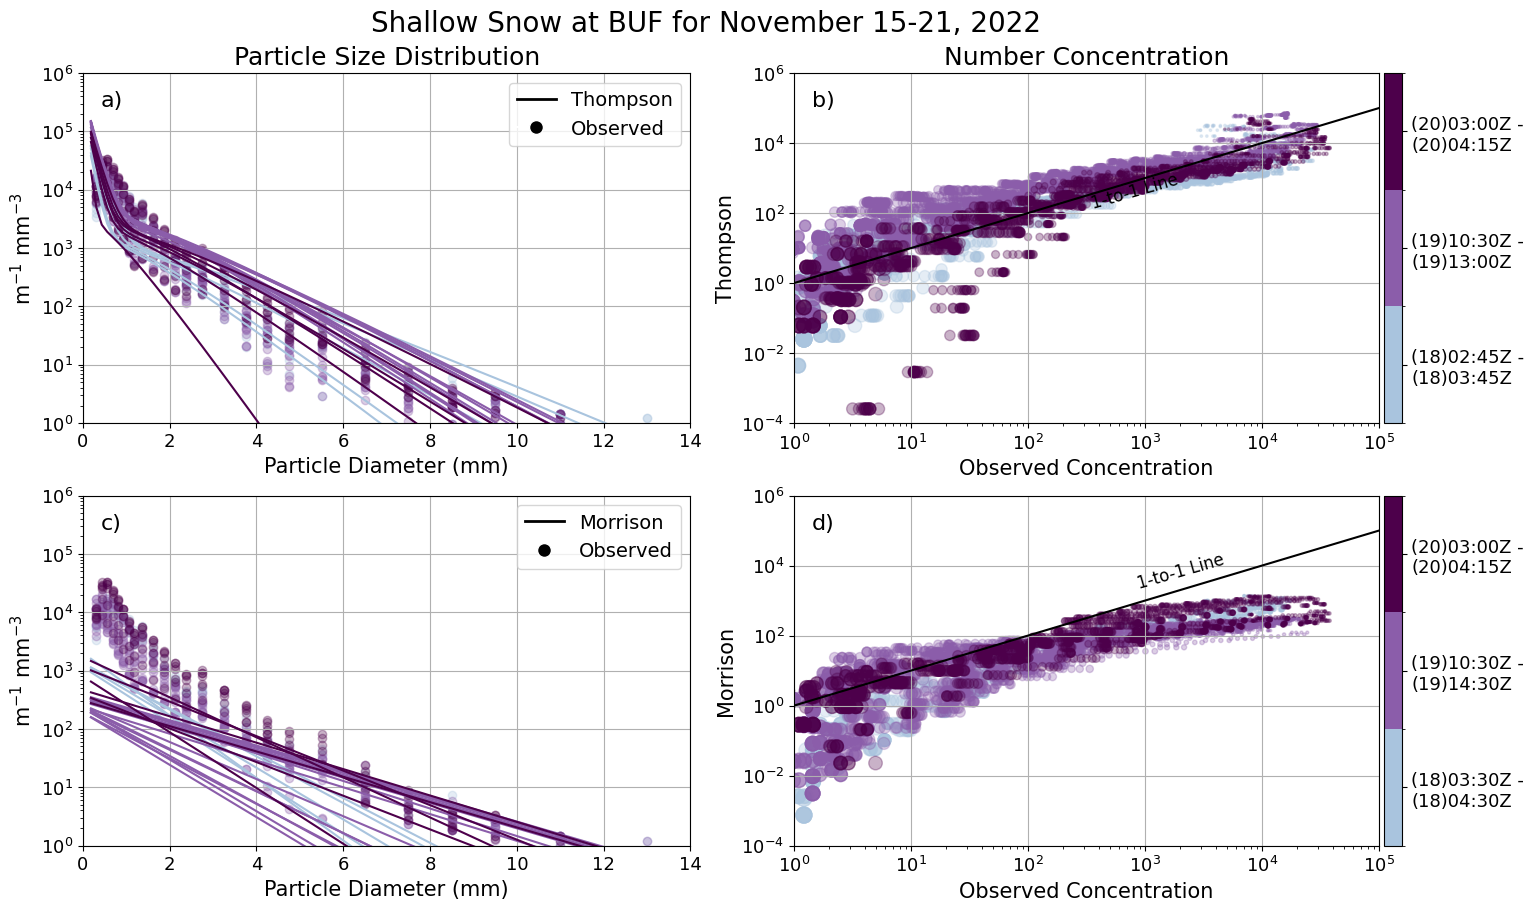

In [29]:
# create 2-panel plot: left two are the observed points vs. model lines
# right is a 1-to-1 line plot
import matplotlib

fig, axs  = plt.subplot_mosaic([[0,1],
                                [2,3]],
                              figsize=(14, 9), layout="constrained")

titdict = {'thom_ruc':'Thompson','morr_ruc':'Morrison'}

# cmap = matplotlib.cm.get_cmap(cmocean.cm.thermal)
cmap = matplotlib.cm.get_cmap('BuPu')

for r,run_dir in enumerate(['thom_ruc','morr_ruc']):
    ax = axs[r*2]
    ax.set_yscale('log')
    
    ax.grid('on',zorder=-1)
    
    strt = 0
    for i in range(ob_psd[r].shape[0]):
#         print(bins[strt:].shape,ob_psd[r][i][strt+1:].shape)
        s = ax.scatter(bins[strt:],ob_psd[r][i][strt:],alpha=0.3,zorder=1,
#                        bins[strt:][3:],ob_psd[r][i][strt:][3:],alpha=0.3,
                       #s=((ob_psd.shape[0]-i)*.5),
#                      color=cmap(i/ob_psd[r].shape[0]))
                       color=cmap((index_cat[r][i]+1)/(np.max(index_cat[r])+1)))
        ax.set_xlim(0,14)
        ax.set_ylim(10e-1,10e5)

    for j in range(ND[r].shape[0]):
        p = ax.plot(bins[strt:],ND[r][j][strt:]/1000,zorder=2,
#                     color=cmap(j/ND[r].shape[0]))
                    color=cmap((index_cat_sm[r][j]+1)/(np.max(index_cat_sm[r])+1)))

    # ax.set_ylabel('# of Particles')
    ax.set_ylabel('m$^{-1}$ mm$^{-3}$')
    ax.set_xlabel('Particle Diameter (mm)')

    custom_line = [Line2D([0],[0],color='k',lw=2,linestyle='-'),
                   Line2D([0],[0],marker='o',color='w',markerfacecolor='k',markersize=10)]
    from matplotlib.legend import Legend
    newlegend = Legend(ax,handles=custom_line,labels=[titdict[run_dir],'Observed'],
                       fontsize=14,loc='upper right')
    ax.add_artist(newlegend)
    
    ###### Second Subplot: 1-to-1 line
    ax = axs[(r*2)+1]
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(10e-5,10e5)
    ax.set_xlim(10e-1,10e4)
    
    ax.grid('on',zorder=-1)
    
    color_list = []
#     print(bins[strt:]*10)
    for i in range(ob_psd[r].shape[0]):
#         print(ob_psd[r][i][strt:].shape,wrf_match[r][i][strt:].shape)
        ax.scatter(ob_psd[r][i][strt:],wrf_match[r][i][strt:],
#                    ob_psd[r][i][strt:][3:],wrf_match[r][i][strt::][3:-1],
                   s=bins[strt:]*10,
#                    s=bins[strt:][3:]*10,
#                    facecolors='none',
                   alpha = 0.3,zorder=1,
#                    color=cmap(i/ob_psd[r].shape[0]))
                   color=cmap((index_cat[r][i]+1)/(np.max(index_cat[r])+1)),
                  )
        
    ax.plot([10e-1,10e5],[10e-1,10e5],color='k',zorder=2)
    if 'thom' in run_dir:
        ax.text(2000,1700,'1-to-1 Line',rotation=16,ha='right',va='top',fontsize=12)
    if 'morr' in run_dir:
        ax.text(2000,1700,'1-to-1 Line',rotation=16,ha='center',va='bottom',fontsize=12)
        
    ax.set_ylabel(f'{titdict[run_dir]}')
    ax.set_xlabel(f'Observed Concentration')
    

    prev = [timeplot[r][0].hour,timeplot[r][0].day]
    timeindices = []
    for t,tt in enumerate(timeplot[r]):
        if (tt.hour!=prev[0])|(tt.day!=prev[1]):
            timeindices.append(t)
            prev = [tt.hour,tt.day]

            
    tstart_w,tend_w = get_case_times(station, snow_type, 'wrf', run_dir, date=dateo)
    print(tstart_w,tend_w)
    tstart_o,tend_o = get_case_times(station, snow_type, 'obs', run_dir, date=dateo)
    format_list = []
    for start,end in zip(tstart_w.strftime('(%d)%H:%M'),tend_w.strftime('(%d)%H:%M')):
        format_list.append(start+'Z - \n'+end+'Z')
        
    divider = make_axes_locatable(ax)
    cax     = divider.append_axes('right', size='3%', pad=0.05)
    bounds  = np.linspace(0, int(index_cat[r].max())+1, num=int(index_cat[r].max())+2)
    color_list = []
    for i in range(int(index_cat[0].max())+1):
        color_list.append(cmap((i+1)/(np.max(index_cat[0])+1)))
    cmapc = mpl.colors.ListedColormap(color_list)
    norm  = mpl.colors.BoundaryNorm(bounds, cmapc.N)
    cb    = mpl.colorbar.ColorbarBase(cax, cmap=cmapc, norm=norm,
                                      spacing='proportional', 
                                      ticks=bounds[:-1]+0.5,
                                      boundaries=bounds)
    cb.set_ticklabels(format_list)

    axs[0].set_title('Particle Size Distribution',fontsize=mb)
    axs[1].set_title('Number Concentration',fontsize=mb)
    
    print(f'done with axs[{r}]')

for l,letter in enumerate(['a)','b)','c)','d)']):
    axs[l].text(0.03,0.95,letter,transform=axs[l].transAxes,ha='left',va='top',
                bbox={'facecolor':'w','alpha':0.5,'edgecolor':'none'},fontsize=16)
    
if isinstance(dateo,int):
    datestr =f'_2022{dateo:02d}'
elif isinstance(dateo,list):
    datestr=f'_2022{dateo[0].month:02d}{dateo[0].day:02d}-{dateo[0].hour:02d}'
elif dateo == None:
    datestr=''
else:
    datestr=f'_2022{dateo.month:02d}{dateo.day:02d}-{dateo.hour:02d}'

if snow_type is not None:
    snowstr = f'_{snow_type}'
elif snow_type is None:
    snowstr = ''

titledict = {'case':{1:'January 18-20, 2022',11:'November 15-21, 2022',12:'December 21-27, 2022',
                     'lwe_pos':'Positive LWE Bias','lwe_neg':'Negative LWE Bias',
                     'rho_pos':'Positive SLR Bias','rho_neg':'Negative SLR Bias',
                     'rhosp_pos':'Positive SLR* Bias','rhosp_neg':'Negative SLR* Bias'},
             'snowtype':{'shallow':'Shallow',None:'All','deep':'Deep'}}
if dateo is not None:
    plt.suptitle(f'{titledict["snowtype"][snow_type]} Snow at {station[1:]} for {titledict["case"][dateo]}')
elif varbias is not None:
    plt.suptitle(f'{titledict["snowtype"][snow_type]} Snow at {station[1:]} for {titledict["case"][varbias]}')

# plt.savefig(f'/nfs/turbo/seas-hutsona/les_analysis/figures/psd_{station}_{datestr}.png',
#             bbox_inches='tight',dpi=250)

In [17]:
bounds[:-1]+0.5
format_list

['(20)02:45Z - \n(20)03:15Z', '(20)11:00Z - \n(20)13:00Z']

## Heat Map for 1-to-1 Line

In [51]:
small, med,mb, big = 11, 13, 15, 17
# plt.rc('font',size=med)
plt.rc('axes',titlesize=med, labelsize=med)
plt.rc('xtick',labelsize=small)
plt.rc('ytick',labelsize=small)
plt.rc('legend',fontsize=med)
plt.rc('figure',titlesize=big)

d_bins = np.array([ 0.1,  0.3,  0.5,  0.7,  0.9,  1.1,  1.3,  1.5,  1.7,  1.9,  2.1,
        2.3,  2.5,  2.7,  2.9,  3.1,  3.3,  3.5,  3.7,  3.9,  4.1,  4.3,
        4.5,  4.7,  4.9,  5.1,  5.3,  5.5,  5.7,  5.9,  6.1,  6.3,  6.5,
        6.7,  6.9,  7.1,  7.3,  7.5,  7.7,  7.9,  8.1,  8.3,  8.5,  8.7,
        8.9,  9.1,  9.3,  9.5,  9.7,  9.9, 10.1, 10.3, 10.5, 10.7, 10.9,
       11.1, 11.3, 11.5, 11.7, 11.9, 12.1, 12.3, 12.5, 12.7, 12.9, 13.1,
       13.3, 13.5, 13.7, 13.9, 14.1, 14.3, 14.5, 14.7, 14.9, 15.1, 15.3,
       15.5, 15.7, 15.9, 16.1, 16.3, 16.5, 16.7, 16.9, 17.1, 17.3, 17.5,
       17.7, 17.9, 18.1, 18.3, 18.5, 18.7, 18.9, 19.1, 19.3, 19.5, 19.7,
       19.9, 20.1, 20.3, 20.5, 20.7, 20.9, 21.1, 21.3, 21.5, 21.7, 21.9,
       22.1, 22.3, 22.5, 22.7, 22.9, 23.1, 23.3, 23.5, 23.7, 23.9, 24.1,
       24.3, 24.5, 24.7, 24.9, 25.1, 25.3, 25.5, 25.7, 25.9, 26. ])


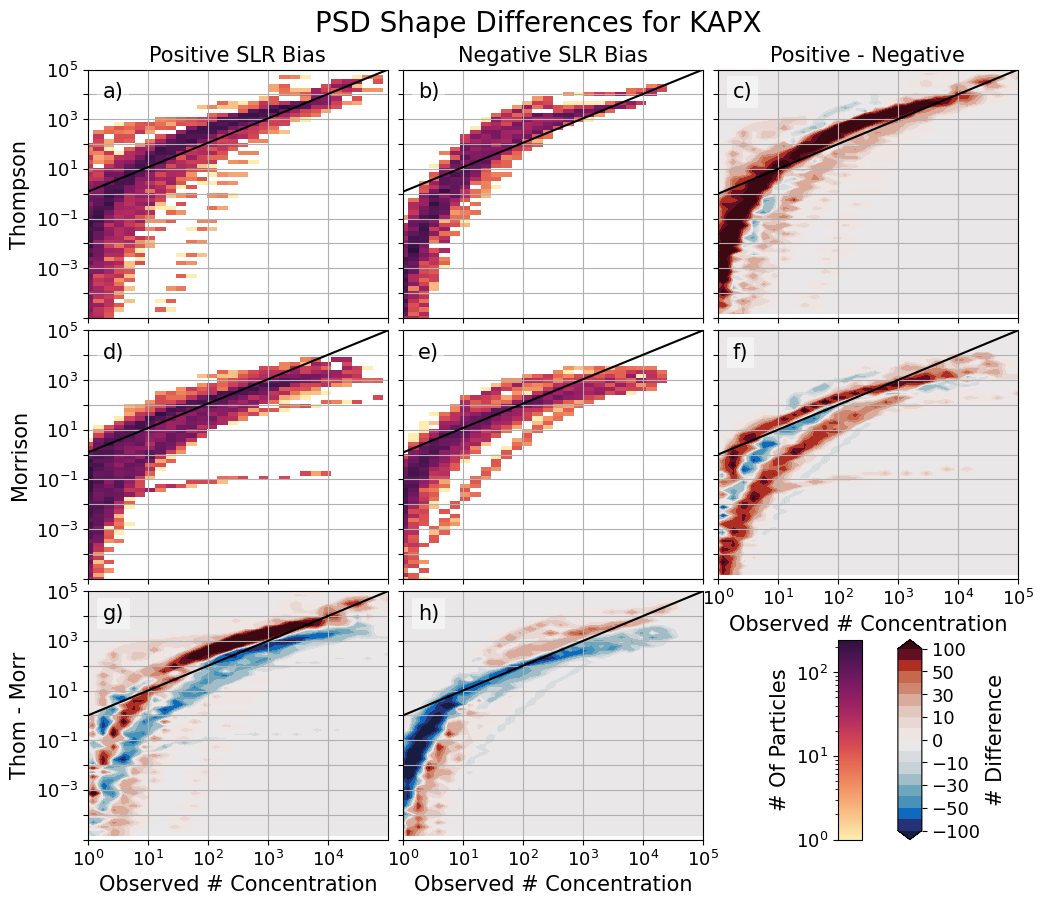

In [7]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import FormatStrFormatter

station  ='KAPX'
var      = 'rho'
plottype = 'psd' #one2one

titdict={'lwe':'LWE','rho':'SLR','rho_sp':'SLR$_{snowpack}$'}

# Read in all pre-saved ob and "wrf-match" data
heat_ob_tp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob_psd_{station}_t{var}_pos.npy')
try:
    heat_ob_tn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob_psd_{station}_t{var}_neg.npy')
except:
    heat_ob_tn = np.zeros_like(heat_ob_tp)

heat_ob_mp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob_psd_{station}_m{var}_pos.npy')
heat_ob_mn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob_psd_{station}_m{var}_neg.npy')
heat_ob_all= [heat_ob_tp,heat_ob_tn,heat_ob_mp,heat_ob_mn]

heat_wrf_tp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf_psd_{station}_t{var}_pos.npy')
try:
    heat_wrf_tn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf_psd_{station}_t{var}_neg.npy')
except:
    heat_wrf_tn = np.zeros_like(heat_wrf_tp)
heat_wrf_mp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf_psd_{station}_m{var}_pos.npy')
heat_wrf_mn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf_psd_{station}_m{var}_neg.npy')
heat_wrf_all= [heat_wrf_tp,heat_wrf_tn,heat_wrf_mp,heat_wrf_mn]

heatmap_all = []
for i in range(len(heat_ob_all)):
    heat_ob = heat_ob_all[i]
    heat_wrf= heat_wrf_all[i]
        
    if plottype == 'one2one':
        # Need to remove NaNs for histogram2d!
        bad_indices = np.isnan(heat_ob.flatten()) | np.isnan(heat_wrf.flatten())
        good_indices = ~bad_indices
        good_x = heat_ob.flatten()[good_indices]
        good_y = heat_wrf.flatten()[good_indices]

        # important to bin in logarithmic space!
        hm_bins = np.logspace(-5,5,num=60)
        # get heatmap with edges
        heatmap, xedges, yedges = np.histogram2d(good_x, good_y, bins=hm_bins)
        extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

        heatmap_all = heatmap_all + [heatmap]
        
    elif plottype == 'psd':
        e_bins = list(-np.logspace(-5,5,num=30)[::-1])+list(np.logspace(-5,5,num=30))

        error = heat_wrf_all[i]-heat_ob_all[i]
        herror= np.zeros((np.shape(e_bins)[0]-1,error.shape[-1]))
        
        for i in range(len(d_bins)):
            good_idx = ~(np.isnan(error[:,i]))
            a,b= np.histogram(error[:,i][good_idx],bins=e_bins)
            herror[:,i] = a
            
        herror[herror==0] = np.nan
        heatmap_all = heatmap_all + [herror]


fig,axs = plt.subplots(3,3,
                       figsize=(12,10))

textdict = {0:'a)',1:'b)',2:'c)',3:'d)',4:'e)',
            5:'f)',6:'g)',7:'h)',8:'i)'}

for a,ax in enumerate(axs.flatten()):    

    if a<2:
        heatmap = heatmap_all[a]
    if (a==3)|(a==4):
        heatmap = heatmap_all[a-1]
        
    if a==2:
        heatmap = heatmap_all[0]-heatmap_all[1]
    if a==5:
        heatmap = heatmap_all[2]-heatmap_all[3]
    if a==6:
        heatmap = heatmap_all[0]-heatmap_all[2]
    if a==7:
        heatmap = heatmap_all[1]-heatmap_all[3]

    # Begin Figure
    if (a<2)|(a==3)|(a==4):
        cmap = cmocean.cm.matter
        if heatmap.max()>0:
            im = ax.imshow(heatmap.T,origin='lower',
                           aspect='auto',
                           cmap=cmap,
                           norm=LogNorm(),
                          )
#         ax.plot([0,len(heatmap[0])],[0,len(heatmap[1])],color='w',linewidth=3)
        ax.plot([0,len(heatmap[0])],[0,len(heatmap[1])],color='k',linestyle='-')
        tick_start = np.argwhere(xedges>=1)[0][0]
        tick_end   = len(heatmap.T[0])
        tickslocx  = np.linspace(tick_start,tick_end,num=6)
        tickslocy  = np.linspace(0,tick_end,num=11)
        
        # All axis ticks need to be hardcoded into log notation. Be WEARY!
        ax.set_xlim(np.argwhere(xedges>=1)[0][0],len(heatmap.T[0])-1)
        ax.set_ylim(0,len(heatmap.T[0])-1)
        ax.set_xticks(tickslocx,labels=['10$^0$','10$^1$','10$^2$','10$^3$','10$^4$','10$^5$'])
        if (a==0)|(a==3):
            ax.set_yticks(tickslocy,labels=['','','10$^{-3}$','','10$^{-1}$','','10$^1$','','10$^3$','','10$^5$'])
        else:
            ax.set_yticks(tickslocy,labels=[])
        ax.set_xticklabels([])
      
    elif a==8:
        ax.set_axis_off()
        
    else:
        cmap = cmocean.cm.balance
#         ax.plot([0,10e4],[0,10e4],color='w',linestyle='-',linewidth=3)
        ax.plot([0,10e4],[0,10e4],color='k',linestyle='-')
        cf = ax.contourf(hm_bins[1:],hm_bins[1:],heatmap.T,
                         levels=[-100,-75,-50,-40,-30,-15,-10,-5,0,5,10,15,30,40,50,75,100],
                         cmap=cmap,extend='both')
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_ylim(10e-5,10e4)
        ax.set_xlim(10e-1,10e4)
        ax.yaxis.set_ticks([10e-6,10e-5,10e-4,10e-3,10e-2,10e-1,10e0,10e1,10e2,10e3,10e4])
        if a<5:
            ax.set_xticklabels([])
        if a!=6:
            ax.set_yticklabels([])
            ax.xaxis.set_ticks([10e-1,10e-0,10e1,10e2,10e3,10e4])
        else:
            ax.xaxis.set_ticks([10e-1,10e-0,10e1,10e2,10e3])
            ax.set_yticklabels(['','','10$^{-3}$','','10$^{-1}$','','10$^1$','','10$^3$','','10$^5$'])
                
    ax.grid('on',zorder=0)

    if a<8:
        ax.text(0.05,0.95,textdict[a],fontsize=med,
                ha='left',va='top',transform=ax.transAxes,
                bbox={'facecolor':'w','alpha':0.5,'edgecolor':'none'})
    

axs[0][0].set_title(f'Positive {titdict[var]} Bias')
axs[0][1].set_title(f'Negative {titdict[var]} Bias')
axs[0][2].set_title(f'Positive - Negative')

axs[0][0].set_ylabel(f'Thompson')
axs[1][0].set_ylabel(f'Morrison')
axs[2][0].set_ylabel(f'Thom - Morr')

axs[1][2].set_xlabel('Observed # Concentration')
for i in [0,1]:
    axs[2][i].set_xlabel('Observed # Concentration')

cax = fig.add_axes([0.75, 0.11, 0.02, 0.2]) #x0,y0,width,height
plt.colorbar(im,cax=cax,orientation='vertical',label='# Of Particles')
cax.yaxis.set_ticks_position('left')
cax.yaxis.set_label_position('left')
cax = fig.add_axes([0.8, 0.11, 0.02, 0.2]) #x0,y0,width,height
plt.colorbar(cf,cax=cax,orientation='vertical',label='# Difference')
    
plt.subplots_adjust(wspace=0.05, hspace=0.05)

plt.suptitle(f'PSD Shape Differences for {station}',
             x=0.5,y=0.94)

plt.savefig(f'/nfs/turbo/seas-hutsona/les_analysis/figures/biasdiffs_{station}_{var}.png')


debugging (79, 131)
db2 (131,) (79,)
debugging (79, 131)
db2 (131,) (79,)
debugging (79, 131)
db2 (131,) (79,)
debugging (79, 131)
db2 (131,) (79,)


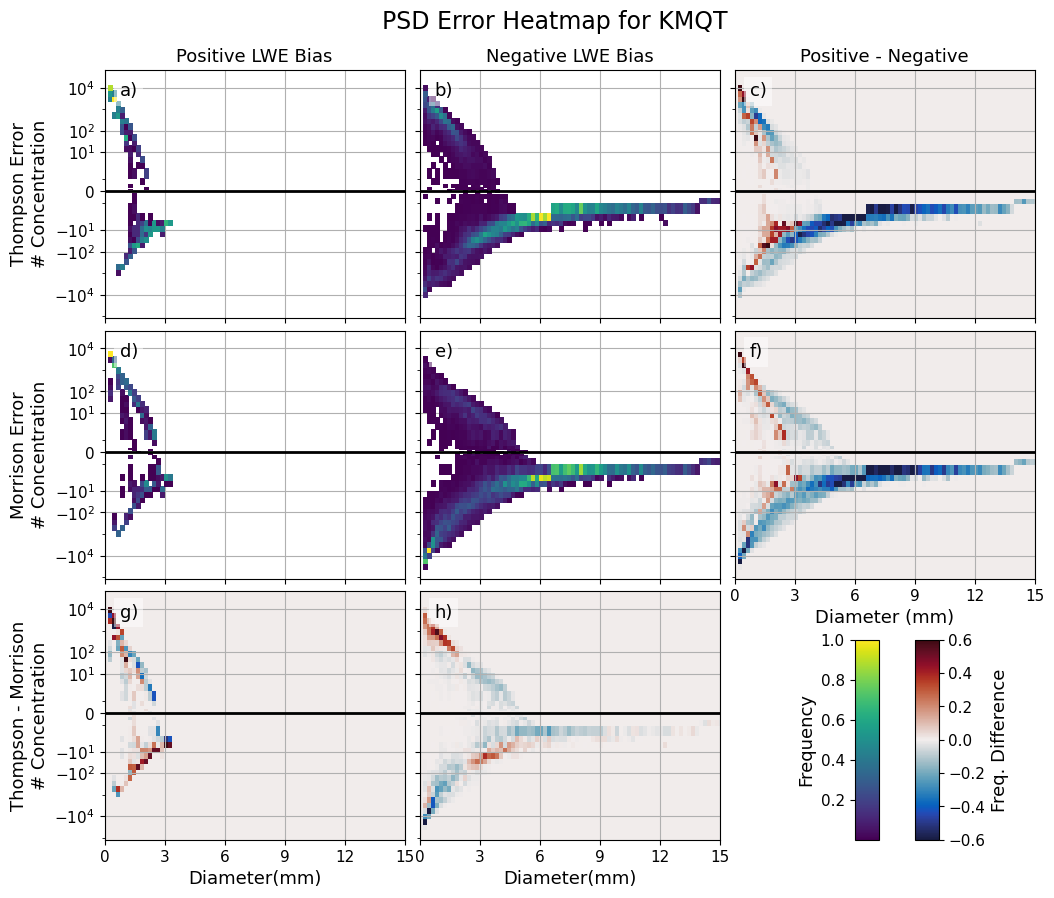

In [52]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import FormatStrFormatter

station  ='KMQT'
var      = 'lwe'
fivemin  = False

titdict={'lwe':'LWE','rho':'SLR','rho_sp':'SLR$_{snowpack}$'}
if fivemin==True:
    string = '15'
else:
    string = ''

# Read in all pre-saved ob and "wrf-match" data
heat_ob_mn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob{string}_psd_{station}_m{var}_neg.npy')
try:
    heat_ob_mp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob{string}_psd_{station}_m{var}_pos.npy')
except:
    heat_ob_mp = np.zeros_like(heat_ob_mn)
try:
    heat_ob_tp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob{string}_psd_{station}_t{var}_pos.npy')
except:
    heat_ob_tp = np.zeros_like(heat_ob_mn)
try:
    heat_ob_tn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob{string}_psd_{station}_t{var}_neg.npy')
except:
    heat_ob_tn = np.zeros_like(heat_ob_tp)

heat_ob_all= [heat_ob_tp,heat_ob_tn,heat_ob_mp,heat_ob_mn]

heat_wrf_mn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf{string}_psd_{station}_m{var}_neg.npy')
try:
    heat_wrf_tp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf{string}_psd_{station}_t{var}_pos.npy')
except:
    heat_wrf_tp = np.zeros_like(heat_wrf_mn)
try:
    heat_wrf_tn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf{string}_psd_{station}_t{var}_neg.npy')
except:
    heat_wrf_tn = np.zeros_like(heat_wrf_tp)
try:
    heat_wrf_mp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf{string}_psd_{station}_m{var}_pos.npy')
except:
    heat_wrf_mp = np.zeros_like(heat_wrf_mn)

heat_wrf_all= [heat_wrf_tp,heat_wrf_tn,heat_wrf_mp,heat_wrf_mn]

heatmap_all = []
for i in range(len(heat_ob_all)):
    heat_ob = heat_ob_all[i]
    heat_wrf= heat_wrf_all[i]
        
    e_bins = list(-np.logspace(-5,5,num=40)[::-1])+list(np.logspace(-5,5,num=40))

    error = heat_wrf_all[i]-heat_ob_all[i]
    herror= np.zeros((np.shape(e_bins)[0]-1,error.shape[-1]))

    if station=='KBUF':
        d_bins = np.asarray([ 0.062,0.187,0.312,0.437,0.562,0.687,0.812,0.937,1.062,1.187,
                              1.375,1.625,1.875,2.125,2.375,2.75,3.25,3.75,4.25,4.75,
                              5.5,6.5   , 7.5   , 8.5  ,  9.5 ,  11. ,   13. ,   15.  ,  17.  ,  19.,
                              21.5 ,  24.5  ])
    for j in range(len(d_bins)):
        good_idx = ~(np.isnan(error[:,j]))
        a,b= np.histogram(error[:,j][good_idx],bins=e_bins)
        herror[:,j] = a
        
    # NORMALIZE THE ENTRY HERE!!
    herror = herror/np.nanmax(herror)

    heatmap_all = heatmap_all + [herror]


fig,axs = plt.subplots(3,3,
                       figsize=(12,10))

textdict = {0:'a)',1:'b)',2:'c)',3:'d)',4:'e)',
            5:'f)',6:'g)',7:'h)',8:'i)'}

for a,ax in enumerate(axs.flatten()):    

    if a<2:
        heatmap = heatmap_all[a]
#         heatmap[heatmap==0] = np.nan
    if (a==3)|(a==4):
        heatmap = heatmap_all[a-1]
#         heatmap[heatmap==0] = np.nan
        
    if a==2:
        heatmap = heatmap_all[0]-heatmap_all[1]
    if a==5:
        heatmap = heatmap_all[2]-heatmap_all[3]
    if a==6:
        heatmap = heatmap_all[0]-heatmap_all[2]
    if a==7:
        heatmap = heatmap_all[1]-heatmap_all[3]

    # Begin Figure
      
    if a==8:
        ax.set_axis_off()
        
    else:        
        if (a<2)|(a==3)|(a==4):
            hm_plot = np.copy(heatmap)
            print('debugging',np.shape(hm_plot))
            hm_plot[hm_plot==0] = np.nan
            print('db2',np.shape(d_bins),np.shape(e_bins[:-1]))
            im = ax.pcolor(d_bins,e_bins[:-1],hm_plot,#<--NORMALIZED
                           cmap='viridis',
                           zorder=2,
#                            norm='log',
#                            vmin=0,vmax=300,
                          )
        else:
            cf = ax.pcolor(d_bins,e_bins[:-1],heatmap,
                           cmap=cmocean.cm.balance,
                           zorder=0,
                           vmin=-0.6,vmax=0.6,
                           )
        
        ax.set_yscale('symlog')
        ax.set_yticks([-10e3,-10e1,-10e0,0,10e0,10e1,10e3])
        ax.grid('on',zorder=1)
        ax.set_xlim(0,15)
        ax.set_xticks(np.arange(0,18,3))
        ax.axhline(y=0,color='k',linewidth=2)
                
    if a<8:
        ax.text(0.05,0.95,textdict[a],fontsize=med,
                ha='left',va='top',transform=ax.transAxes,
                bbox={'facecolor':'w','alpha':0.5,'edgecolor':'none'})
        
    if (a!=0)&(a!=3)&(a!=6):
        ax.set_yticklabels([])
    if (a<5):
        ax.set_xticklabels([])
    

axs[0][0].set_title(f'Positive {titdict[var]} Bias')
axs[0][1].set_title(f'Negative {titdict[var]} Bias')
axs[0][2].set_title(f'Positive - Negative')

axs[0][0].set_ylabel(f'Thompson Error\n# Concentration')
axs[1][0].set_ylabel(f'Morrison Error\n# Concentration')
axs[2][0].set_ylabel(f'Thompson - Morrison\n# Concentration')

axs[1][2].set_xlabel('Diameter (mm)')
for i in [0,1]:
    axs[2][i].set_xlabel('Diameter(mm)')

cax = fig.add_axes([0.75, 0.11, 0.02, 0.2]) #x0,y0,width,height
plt.colorbar(im,cax=cax,orientation='vertical',label='Frequency')
cax.yaxis.set_ticks_position('left')
cax.yaxis.set_label_position('left')
cax = fig.add_axes([0.8, 0.11, 0.02, 0.2]) #x0,y0,width,height
plt.colorbar(cf,cax=cax,orientation='vertical',label='Freq. Difference')
    
plt.subplots_adjust(wspace=0.05, hspace=0.05)

plt.suptitle(f'PSD Error Heatmap for {station}',
             x=0.5,y=0.94)

plt.savefig(f'/nfs/turbo/seas-hutsona/les_analysis/figures/psderror_{station}_{var}.png')


TOTAL -0.0007731467539277029
TOTAL 0.0003163912548815156
TOTAL 0.0025244585367950613


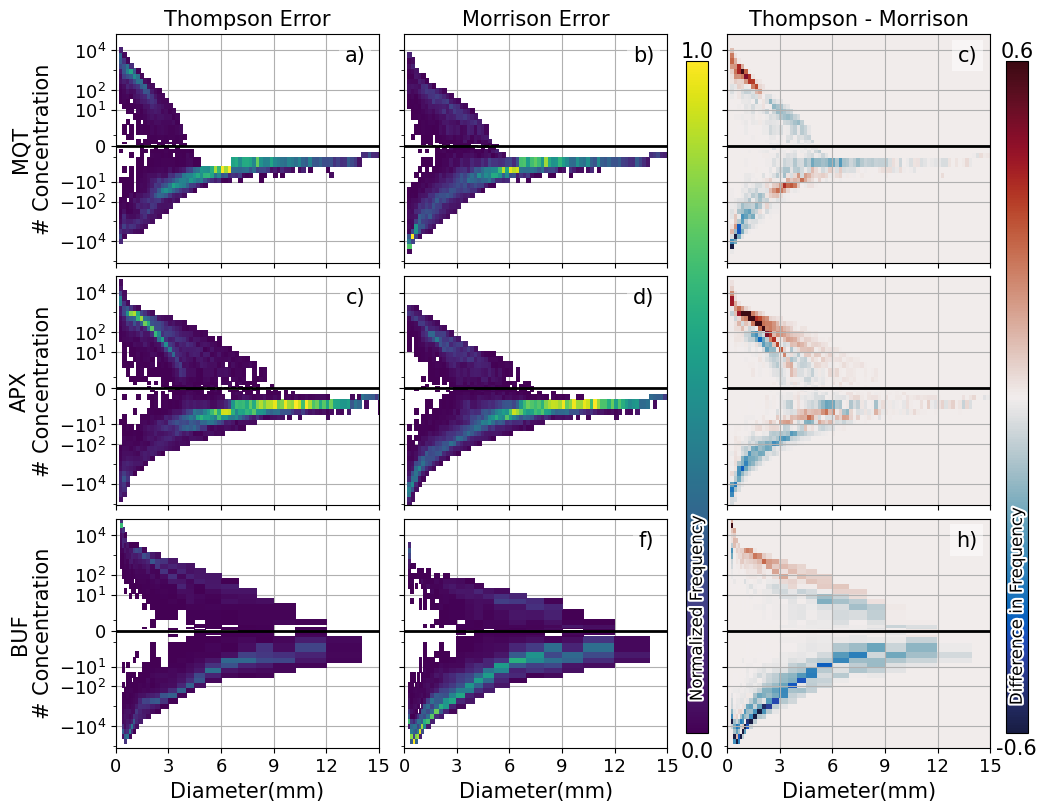

In [62]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe


d_bins = np.array([ 0.1,  0.3,  0.5,  0.7,  0.9,  1.1,  1.3,  1.5,  1.7,  1.9,  2.1,
        2.3,  2.5,  2.7,  2.9,  3.1,  3.3,  3.5,  3.7,  3.9,  4.1,  4.3,
        4.5,  4.7,  4.9,  5.1,  5.3,  5.5,  5.7,  5.9,  6.1,  6.3,  6.5,
        6.7,  6.9,  7.1,  7.3,  7.5,  7.7,  7.9,  8.1,  8.3,  8.5,  8.7,
        8.9,  9.1,  9.3,  9.5,  9.7,  9.9, 10.1, 10.3, 10.5, 10.7, 10.9,
       11.1, 11.3, 11.5, 11.7, 11.9, 12.1, 12.3, 12.5, 12.7, 12.9, 13.1,
       13.3, 13.5, 13.7, 13.9, 14.1, 14.3, 14.5, 14.7, 14.9, 15.1, 15.3,
       15.5, 15.7, 15.9, 16.1, 16.3, 16.5, 16.7, 16.9, 17.1, 17.3, 17.5,
       17.7, 17.9, 18.1, 18.3, 18.5, 18.7, 18.9, 19.1, 19.3, 19.5, 19.7,
       19.9, 20.1, 20.3, 20.5, 20.7, 20.9, 21.1, 21.3, 21.5, 21.7, 21.9,
       22.1, 22.3, 22.5, 22.7, 22.9, 23.1, 23.3, 23.5, 23.7, 23.9, 24.1,
       24.3, 24.5, 24.7, 24.9, 25.1, 25.3, 25.5, 25.7, 25.9, 26. ])

var      = 'lwe'
fivemin  = False

titdict={'lwe':'LWE','rho':'SLR','rho_sp':'SLR$_{snowpack}$'}
if fivemin==True:
    string = '15'
else:
    string = ''

gridspec = dict(hspace=0.0, height_ratios=[1, 1, 0.4, 3])
fig,axs = plt.subplots(3,4,figsize=(10,8),
                       layout='constrained',
                       gridspec_kw={'width_ratios': [1,1,0.1,1], 
                                    'height_ratios': [1,1,1]},
                      )


# #make outer gridspec
# outer = gridspec.GridSpec(2, 1, height_ratios = [1, 6]) 
# #make nested gridspecs
# gs1 = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec = outer[0])
# gs2 = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], hspace = .05)


textdict = {0:'a)',1:'b)',3:'c)',4:'d)',5:'e)',
            7:'f)',8:'g)',9:'h)',11:'i)',2:'',6:'',10:''}

for s,station in enumerate(['KMQT','KAPX','KBUF']):
    # Read in all pre-saved ob and "wrf-match" data
    heat_ob_mn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob{string}_psd_{station}_m{var}_neg.npy')
    try:
        heat_ob_mp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob{string}_psd_{station}_m{var}_pos.npy')
    except:
        heat_ob_mp = np.zeros_like(heat_ob_mn)
    try:
        heat_ob_tp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob{string}_psd_{station}_t{var}_pos.npy')
    except:
        heat_ob_tp = np.zeros_like(heat_ob_mn)
    try:
        heat_ob_tn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/ob{string}_psd_{station}_t{var}_neg.npy')
    except:
        heat_ob_tn = np.zeros_like(heat_ob_tp)

    heat_ob_all= [heat_ob_tp,heat_ob_tn,heat_ob_mp,heat_ob_mn]

    heat_wrf_mn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf{string}_psd_{station}_m{var}_neg.npy')
    try:
        heat_wrf_tp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf{string}_psd_{station}_t{var}_pos.npy')
    except:
        heat_wrf_tp = np.zeros_like(heat_wrf_mn)
    try:
        heat_wrf_tn = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf{string}_psd_{station}_t{var}_neg.npy')
    except:
        heat_wrf_tn = np.zeros_like(heat_wrf_tp)
    try:
        heat_wrf_mp = np.load(f'/nfs/turbo/seas-hutsona/les_analysis/wrf{string}_psd_{station}_m{var}_pos.npy')
    except:
        heat_wrf_mp = np.zeros_like(heat_wrf_mn)

    heat_wrf_all= [heat_wrf_tp,heat_wrf_tn,heat_wrf_mp,heat_wrf_mn]

    heatmap_all = []
    for i in [0,2]:
        heat_ob = np.concatenate((heat_ob_all[i],heat_ob_all[i+1]))
        heat_wrf= np.concatenate((heat_wrf_all[i],heat_wrf_all[i+1]))

        e_bins = list(-np.logspace(-5,5,num=40)[::-1])+list(np.logspace(-5,5,num=40))

        error = heat_wrf-heat_ob
        herror= np.zeros((np.shape(e_bins)[0]-1,error.shape[-1]))
#         print('testing',error.shape, np.shape(herror))

        if station=='KBUF':
            d_bins = np.asarray([ 0.062,0.187,0.312,0.437,0.562,0.687,0.812,0.937,1.062,1.187,
                                  1.375,1.625,1.875,2.125,2.375,2.75,3.25,3.75,4.25,4.75,
                                  5.5,6.5   , 7.5   , 8.5  ,  9.5 ,  11. ,   13. ,   15.  ,  17.  ,  19.,
                                  21.5 ,  24.5  ])
        for j in range(len(d_bins)):
            good_idx = ~(np.isnan(error[:,j]))
            a,b= np.histogram(error[:,j][good_idx],bins=e_bins)
            herror[:,j] = a

        # NORMALIZE THE ENTRY HERE!!
        herror = herror/np.nanmax(herror)

        heatmap_all = heatmap_all + [herror]

    for a,ax in enumerate(axs[s]):    
        # Begin Figure

        if (a<2):
            hm_plot = np.copy(heatmap_all[a])
            hm_plot[hm_plot==0] = np.nan
            im = ax.pcolor(d_bins,e_bins[:-1],hm_plot,#<--NORMALIZED
                           cmap='viridis',
                           zorder=2,
#                            norm='log',
#                            vmin=0,vmax=300,
                          )
        elif a==3:
            cf = ax.pcolor(d_bins,e_bins[:-1],heatmap_all[0]-heatmap_all[1],
                           cmap=cmocean.cm.balance,
                           zorder=0,
                           vmin=-0.6,vmax=0.6,
                           )
            print('TOTAL',np.nanmean(heatmap_all[0]-heatmap_all[1]))
        elif a==2:
            ax.set_visible(False)
                
        ax.set_yscale('symlog')
        ax.set_yticks([-10e3,-10e1,-10e0,0,10e0,10e1,10e3])
        ax.grid('on',zorder=1)
        ax.set_xlim(0,15)
        ax.set_xticks(np.arange(0,18,3))
        ax.axhline(y=0,color='k',linewidth=2)

        ax.text(0.95,0.95,textdict[int(a+(s*3))],fontsize=med,
                ha='right',va='top',transform=ax.transAxes,
                bbox={'facecolor':'w','alpha':0.5,'edgecolor':'none'})

        if a>0:
            ax.set_yticklabels([])
        if s<2:
            ax.set_xticklabels([])
            


axs[0][0].set_title(f'Thompson Error')
axs[0][1].set_title(f'Morrison Error')
axs[0][3].set_title(f'Thompson - Morrison')

axs[0][0].set_ylabel(f'MQT\n# Concentration',fontsize=med)
axs[1][0].set_ylabel(f'APX\n# Concentration',fontsize=med)
axs[2][0].set_ylabel(f'BUF\n# Concentration',fontsize=med)

# axs[1][2].set_xlabel('Diameter (mm)')
for i in [0,1,3]:
    axs[2][i].set_xlabel('Diameter(mm)')

cax = fig.add_axes([0.68, 0.09, 0.022, 0.84]) #x0,y0,width,height
plt.colorbar(im,cax=cax,orientation='vertical',ticks=[])
cax.text(0.5,-0.01,'0.0',fontsize=15,ha='center',va='top')
cax.text(0.5,1.0,'1.0',fontsize=15,ha='center',va='bottom')
cax.text(0.5,0.05,'Normalized Frequency',fontsize=12,ha='center',va='bottom',rotation=90,
         path_effects=[pe.withStroke(linewidth=3, foreground="white")])

cax1 = fig.add_axes([1, 0.09, 0.022, 0.84]) #x0,y0,width,height
plt.colorbar(cf,cax=cax1,orientation='vertical',ticks=[])
cax1.text(0.5,-0.61,'-0.6',fontsize=15,ha='center',va='top')
cax1.text(0.5,0.6,'0.6',fontsize=15,ha='center',va='bottom')
cax1.text(0.5,-0.55,'Difference in Frequency',fontsize=12,ha='center',va='bottom',rotation=90,
         path_effects=[pe.withStroke(linewidth=3, foreground="white")])


# plt.subplots_adjust(wspace=0.05, hspace=0.05)

# plt.suptitle(f'PSD Error Heatmap for {station}',
#              x=0.5,y=0.94)

plt.savefig(f'/nfs/turbo/seas-hutsona/les_analysis/figures/psderror_TvsM.png',dpi=200,bbox_inches='tight')


In [30]:
np.concatenate((heat_ob_all[0],heat_ob_all[1])).shape

(747, 131)

In [70]:
ob_psd,ob_time,bins = get_ob_data(dateo,station,snow_type,run_dir,varbias=varbias)
print(bins)

returning more than one time window
DatetimeIndex(['2022-01-20 09:30:00', '2022-11-18 00:55:00',
               '2022-11-19 06:00:00', '2022-11-20 02:45:00',
               '2022-12-24 00:00:00', '2022-12-25 03:15:00'],
              dtype='datetime64[ns]', freq=None) DatetimeIndex(['2022-01-20 10:30:00', '2022-11-18 01:45:00',
               '2022-11-19 08:00:00', '2022-11-20 04:00:00',
               '2022-12-24 07:00:00', '2022-12-25 06:00:00'],
              dtype='datetime64[ns]', freq=None)
/nfs/turbo/seas-hutsona/les_data/PARSIVEL/20220120_BUF.nc
/nfs/turbo/seas-hutsona/les_data/PARSIVEL/20221118_BUF.nc
/nfs/turbo/seas-hutsona/les_data/PARSIVEL/20221119_BUF.nc
/nfs/turbo/seas-hutsona/les_data/PARSIVEL/20221120_BUF.nc
/nfs/turbo/seas-hutsona/les_data/PARSIVEL/20221224_BUF.nc
/nfs/turbo/seas-hutsona/les_data/PARSIVEL/20221225_BUF.nc
[ 0.062  0.187  0.312  0.437  0.562  0.687  0.812  0.937  1.062  1.187
  1.375  1.625  1.875  2.125  2.375  2.75   3.25   3.75   4.25   4.75
  5.5    

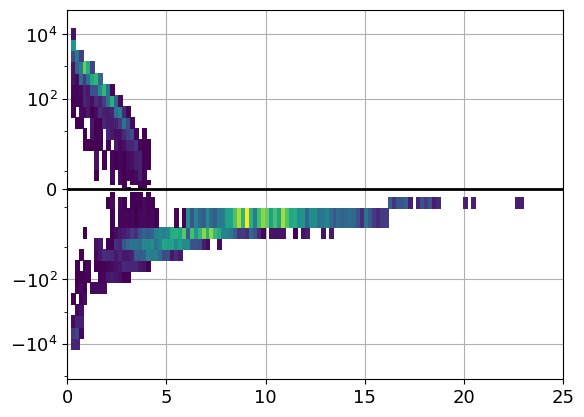

In [68]:

fig,ax = plt.subplots(1,1)
im = ax.pcolor(d_bins,e_bins[:-1],herror,
               cmap='viridis',
               zorder=2)
ax.set_yscale('symlog')
ax.set_yticks([-10e3,-10e1,0,10e1,10e3])
ax.grid('on',zorder=1)
ax.set_xlim(0,25)
ax.axhline(y=0,color='k',linewidth=2)
# ax.axhline(y=(len(e_bins)/2),color='k',linestyle='-')
# tick_start = np.argwhere(xedges>=1)[0][0]
# tick_end   = len(heatmap.T[0])
# tickslocx  = np.linspace(tick_start,tick_end,num=6)
# tickslocy  = np.linspace(0,tick_end,num=11)

# All axis ticks need to be hardcoded into log notation. Be WEARY!
# ax.set_xlim(np.argwhere(xedges>=1)[0][0],len(heatmap.T[0])-1)
# ax.set_ylim(0,len(heatmap.T[0])-1)
# ax.set_xticks(tickslocx,labels=['10$^0$','10$^1$','10$^2$','10$^3$','10$^4$','10$^5$'])
# if (a==0)|(a==3):
#     ax.set_yticks(tickslocy,labels=['','','10$^{-3}$','','10$^{-1}$','','10$^1$','','10$^3$','','10$^5$'])

In [65]:
    
#     if isinstance(dateo,int):
#         titdate = {1:'January 18-20 2022',11:'November 15-21 2022',12:'December 21-27 2022'}
#         datestr =f'_2022{dateo:02d}'

#         hm_title = f'{stdict[snow_type]} Precip Number Concentration:\n{station} {titdate[dateo]}'
        
#     elif dateo == None:
#         if varbias == None:
#             titdate = 'All Cases'
#             datestr = ''
#         else:
#             titdate = {'lwe_pos':'Positive LWE Bias','lwe_neg':'Negative LWE Bias',
#                       'rho_pos':'Positive SLR Bias','rho_neg':'Negative SLR Bias',
#                       'rhosp_pos':'Positive SLR* Bias','rhosp_neg':'Negative SLR* Bias'}
#             datestr = varbias

#             hm_title = f'{stdict[snow_type]} Precip Number Concentration:\n{station} {titdate[varbias]}'
#     # hm_title = f'{stdict[snow_type]} Precip Number Concentration:\n{station} {titdate[dateo]}'
#     ax.set_title(hm_title);

#     if snow_type is not None:
#         snowstr = f'_{snow_type}'

1.0

# Find eDensity Error: Quantify Missing Liquid Water Mass

In [75]:
# Create function with the Huang et al. (2015) equation for density based on diameter size
def huang_density(diameter):
    ''' Finds density (in g/cm^3) with a given snow particle diameter (mm) '''
    density = 0.15*(diameter**(-0.86))
    return density

# Using the bin *centers* defined in the PIP instrument, 
# define the (average) density of each particle that resides in that bin
denss = huang_density(bins) # g cm^-3

# find the number concentration difference between Model and Obs for each bin
diff = wrf_match-ob_psd # number m^-1 mm^-3

# convert density units to g mm^-3
denss = denss*(1/10)*(1/10)*(1/10)

# Find the bias in *density* 
dens_diff = diff*denss

# find RMSE in density for each bin
rmse = np.zeros(len(bins))
for i in range(bins.shape[0]):
    rmse[i] = np.sqrt((1/dens_diff.shape[0])*np.nansum(dens_diff[:,i]**2))
    
total_rmse = np.sqrt((1/dens_diff.size)*np.nansum(dens_diff**2))
mean_bias  = np.nanmean(dens_diff)


In [76]:
print(total_rmse,'g mm^-3')
print(mean_bias,'g mm^-3')
print(np.nanmean(dens_diff,axis=0))

0.07233664943581489 g mm^-3
-0.031014260050790148 g mm^-3
[            nan             nan -1.23560708e-01 -1.73986932e-01
 -1.29132253e-01 -8.26977067e-02 -3.64082948e-02 -2.47636762e-02
 -7.46619174e-03 -2.18203728e-03 -5.61955836e-04 -1.02343402e-03
 -1.75580245e-03 -1.24185194e-03 -1.58516854e-03 -9.45608069e-04
 -8.20981787e-04 -8.16344604e-04 -8.20667253e-04 -6.45179127e-04
 -2.11802990e-04 -9.84675013e-05 -1.85505607e-04 -9.97805533e-05
 -4.17643002e-05 -3.79445889e-05             nan             nan
             nan             nan             nan             nan]


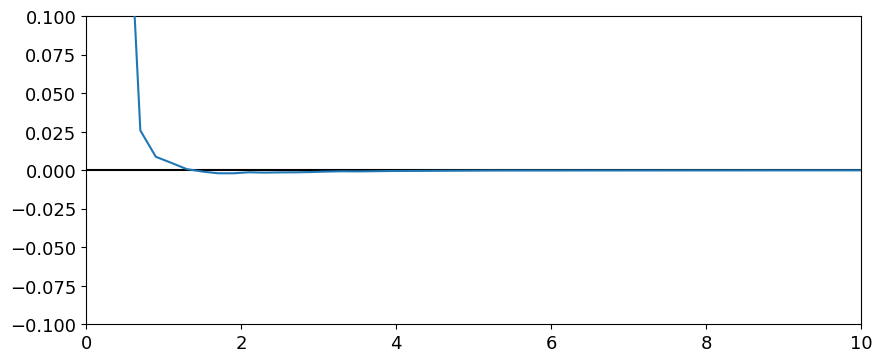

In [39]:
fig,ax = plt.subplots(1,1,figsize=(10,4))
ax.plot(bins,np.nanmean(dens_diff,axis=0),zorder=100)
ax.set_xlim(0,10)
# ax.set_yscale('log')
ax.set_ylim(-0.1,0.1)
ax.axhline(y=0,color='k')

In [45]:
total_rmse

0.39242168790431126

# Find Average Errors Between Obs and MP Schemes

In [7]:
## This code block is ALMOST the same as the one used for plotting
tstart = pd.to_datetime('2022-01-18 14:00:00')
tend   = pd.to_datetime('2022-01-18 19:00:00')

pdtime_range = pd.date_range(start=tstart,
                             end=tend,
                             freq='1H')#<-- Important!
station = 'KMQT'
run_dir = 'thom_ruc'

# Goal: compare each WRF time to a 15 minute window of obs surrounding the WRF time

if tstart.day != tend.day:
    append = True
    days = [tstart.day]
    prevday = tstart.day
    for t in pdtime_range:
        if t.day != prevday:
            days.append(t.day)
        prevday = t .day
else:
    append = False
    
    
if append == True:
    time = []
    for f,day in enumerate(days):
        ftime_str = f'{station}{tstart.year}{tstart.month:02d}{day:02d}2350_01_dsd.nc'
        file = f'/nfs/turbo/seas-ayumif/hutsona/les_analysis/psd_obs/{ftime_str}'
        fh = xr.open_dataset(file)

        psd1 = fh.psd.data
        if f==0:
            psd = psd1
        else:
            psd = np.concatenate((psd,psd1))
        time.append(pd.to_datetime(fh.time.data))
        bins= fh.bin_centers.data
        
if append == False:
    ftime_str = f'{station}{tstart.year}{tstart.month:02d}{tstart.day:02d}2350_01_dsd.nc'
    file = f'/nfs/turbo/seas-ayumif/hutsona/les_analysis/psd_obs/{ftime_str}'
    fh = xr.open_dataset(file)

    psd = fh.psd.data
    time= pd.to_datetime(fh.time.data)
    bins= fh.bin_centers.data
    
istart = np.where(time==pd.to_datetime(tstart))[0][0]
iend   = np.where(time==pd.to_datetime(tend))[0][0]

# ob_psd = psd[istart:iend] # don't need this line

if 'morr' in run_dir:
    Ds,ND = find_psd_morr(pdtime_range[:-1],station,run_dir,bins=bins/1000)
elif 'thom' in run_dir:
    Ds,ND = find_psd_thom(pdtime_range[:-1],station,run_dir,bins=bins/1000)
    
# Don't forget the units issue!!!
ND=ND/1000
# print(ND[4:8,0])
# print(pdtime_range[:-1])

/nfs/ayumif/projects/climatepy/lib/python3.9/site-packages/xarray/coding/variables.py:142: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  condition |= data == fv


wrfout_d01_2022-01-18_14:00:00
wrfout_d01_2022-01-18_15:00:00
wrfout_d01_2022-01-18_16:00:00
wrfout_d01_2022-01-18_17:00:00
wrfout_d01_2022-01-18_18:00:00


In [8]:
wrftime = pd.date_range(start=tstart,
                        end=tend,
                        freq='15min')[:-1]

nd_none  = ND<1   # mask array showing where simulated PSD predicts no particles
psd_none = psd==0 # mask array showing where observed PSD predicts no particles

ND[nd_none] = 0.0
tw = []
nd_error = np.zeros_like(ND)
for wt,wtime in enumerate(wrftime):
    # find 15 min window of observations surrounding wrf time
    tw_b = wtime-pd.Timedelta(minutes=7)
    tw_e = wtime+pd.Timedelta(minutes=7)
    tw.append((tw_b,tw_e))
    
    ib = np.argwhere(time==tw_b)[0][0]
    ie = np.argwhere(time==tw_e)[0][0]
    
    if wt==0:
        test = np.nanmean(psd[ib:(ie+1)],axis=0)
    tw_psd = psd[ib:(ie+1)]
#     print(tw_psd)
    
    nd_error_15 = np.zeros_like(tw_psd)
    for i in range(len(tw_psd)):
#         if wt<4:
#             print(ND[wt][1],tw_psd[i][1])
        nd_error_15[i] = ND[wt] - tw_psd[i]
#         print(ND[wt] - tw_psd[i])
        
    nd_error[wt] = np.nanmean(nd_error_15,axis=0)

/tmp/ipykernel_3660186/3925697378.py:21: RuntimeWarning: Mean of empty slice
  test = np.nanmean(psd[ib:(ie+1)],axis=0)
/tmp/ipykernel_3660186/3925697378.py:32: RuntimeWarning: Mean of empty slice
  nd_error[wt] = np.nanmean(nd_error_15,axis=0)


(0.0, 10.0)

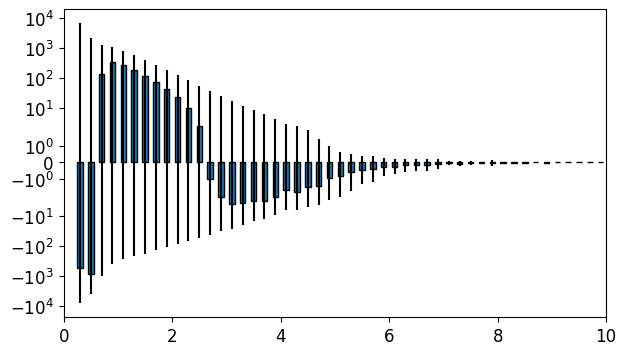

In [13]:
# plot histogram of average simulated error

nd_error_mean = np.nanmean(nd_error,axis=0)
nd_error_std  = np.nanstd(nd_error, axis=0)

fig,ax = plt.subplots(1,1,figsize=(7,4))

ax.set_yscale('symlog')
ax.bar(bins[1:], nd_error_mean[1:],edgecolor='k',width=0.1,yerr=nd_error_std[1:])
ax.set_xlim(0,10)



# Compare N_0 and Lambda Directly

The following code I will most likely not be using. I will not be directly comparing N0s and Lambdas.


In [ ]:
# tstart = pd.to_datetime('2022-01-18 17:00:00')
# tend   = pd.to_datetime('2022-01-18 19:00:00')

# pdtime_range = pd.date_range(start=tstart,
#                              end=tend,
#                              freq='1H')#<-- Important!
# station = 'KMQT'
# run_dir = 'thom_ruc'
    
# if tstart.day != tend.day:
#     append = True
#     days = [tstart.day]
#     prevday = tstart.day
#     for t in pdtime_range:
#         if t.day != prevday:
#             days.append(t.day)
#         prevday = t .day
# else:
#     append = False
    
    
# if append == True:
#     time = []
#     for f,day in enumerate(days):
#         ftime_str = f'{station}{tstart.year}{tstart.month:02d}{day:02d}2350_01_dsd.nc'
#         file = f'/nfs/turbo/seas-ayumif/hutsona/les_analysis/psd_obs/{ftime_str}'
#         fh = xr.open_dataset(file)

#         psd1 = fh.psd.data
#         if f==0:
#             psd = psd1
#         else:
#             psd = np.concatenate((psd,psd1))
#         time.append(pd.to_datetime(fh.time.data))
#         bins= fh.bin_centers.data
        
# if append == False:
#     ftime_str = f'{station}{tstart.year}{tstart.month:02d}{tstart.day:02d}2350_01_dsd.nc'
#     file = f'/nfs/turbo/seas-ayumif/hutsona/les_analysis/psd_obs/{ftime_str}'
#     fh = xr.open_dataset(file)

#     psd = fh.psd.data
#     time= pd.to_datetime(fh.time.data)
#     bins= fh.bin_centers.data
    
# istart = np.where(time==pd.to_datetime(tstart))[0][0]
# iend   = np.where(time==pd.to_datetime(tend))[0][0]

# ob_psd = psd[istart:iend]
# N0s,Lambdas = ob_n0_lambda(ob_psd,bins,running_mean=True)

# N0s_mean = np.empty(int(N0s.shape[0]/15))
# Ls_mean = np.empty(int(N0s.shape[0]/15))
# for i in range(int(N0s.shape[0]/15)):
#     N0s_mean[i] = np.mean(N0s[(i*15):(i*15)+15])
#     Ls_mean[i] = np.mean(Lambdas[(i*15):(i*15)+15])

    
    
    
# if 'morr' in run_dir:
#     ND,n_0s,slopes = find_psd_morr(pdtime_range[:-1],station,run_dir,bins=bins/1000,return_slope=True)
    
# elif 'thom' in run_dir:
#     Ds,ND = find_psd_thom(pdtime_range[:-1],station,run_dir,bins=bins/1000)
#     # Thompson scheme doesn't use a slope or N0 to find shape, so we must use curve fit to get them ourselves
#     n_0s,slopes = np.zeros_like(ND[1:,0]),np.zeros_like(ND[1:,0])
#     for i in range(np.shape(ND[1:])[0]):
#         params = curve_fit(lambda x,N0,Lambda: N0*np.exp(-Lambda*x),
#                            bins[2:],# this [2:] is important because the curvefit wants to fit only the upper slope otherwise
#                            ND[1:,2:][i]/1000)
#         n_0s[i],slopes[i] = params[0][0],params[0][1]